In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models
from datasets import load_dataset, Dataset
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

dataset = load_dataset("beans")

In [ ]:
dataset = load_dataset("beans")
train_dataset = dataset["train"]
val_dataset = dataset["validation"]
test_dataset = dataset["test"]


print(f"Train size: {len(train_dataset)}, Validation size: {len(val_dataset)}")
print(f"Classes: {train_dataset.features['labels'].names}")

num_classes = len(train_dataset.features["labels"].names)
print(f"Number of classes: {num_classes}")

Train size: 1034, Validation size: 133
Classes: ['angular_leaf_spot', 'bean_rust', 'healthy']
Number of classes: 3


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


def apply_train_transform(examples):
    examples["image"] = [train_transform(img.convert("RGB")) for img in examples["image"]]
    return examples

def apply_val_test_transform(examples):
    examples["image"] = [val_test_transform(img.convert("RGB")) for img in examples["image"]]
    return examples

train_dataset = train_dataset.map(apply_train_transform, batched=True)
val_dataset = val_dataset.map(apply_val_test_transform, batched=True)
test_dataset = test_dataset.map(apply_val_test_transform, batched=True)


train_dataset.set_format(type="torch", columns=["image", "labels"])
val_dataset.set_format(type="torch", columns=["image", "labels"])
test_dataset.set_format(type="torch", columns=["image", "labels"])

In [ ]:
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {device}")

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

Устройство: cuda


In [ ]:



model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)


In [ ]:

num_epochs = 10
train_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for batch in train_loader:
        images = batch["image"].to(device)
        labels = batch["labels"].to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)


    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in val_loader:
            images = batch["image"].to(device)
            labels = batch["labels"].to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    val_accuracies.append(accuracy)
    print(f"Эпоха {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f} | Val Acc: {accuracy:.2f}%")

Эпоха 1/10 | Loss: 0.7942 | Val Acc: 77.44%
Эпоха 2/10 | Loss: 0.5215 | Val Acc: 72.93%
Эпоха 3/10 | Loss: 0.4249 | Val Acc: 83.46%
Эпоха 4/10 | Loss: 0.3888 | Val Acc: 87.97%
Эпоха 5/10 | Loss: 0.3431 | Val Acc: 87.22%
Эпоха 6/10 | Loss: 0.3245 | Val Acc: 81.20%
Эпоха 7/10 | Loss: 0.2940 | Val Acc: 87.22%
Эпоха 8/10 | Loss: 0.3321 | Val Acc: 87.22%
Эпоха 9/10 | Loss: 0.2868 | Val Acc: 90.98%
Эпоха 10/10 | Loss: 0.2592 | Val Acc: 90.98%


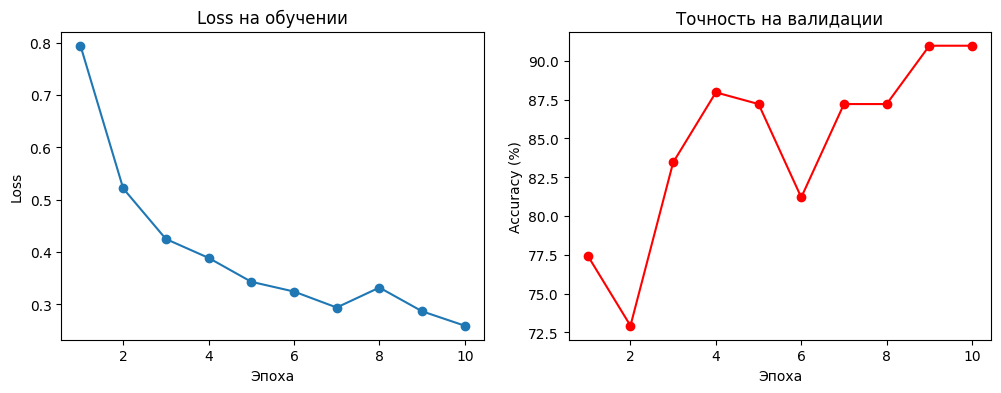

In [ ]:

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, marker='o')
plt.title("Loss на обучении")
plt.xlabel("Эпоха")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), val_accuracies, marker='o', color='red')
plt.title("Точность на валидации")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy (%)")
plt.show()

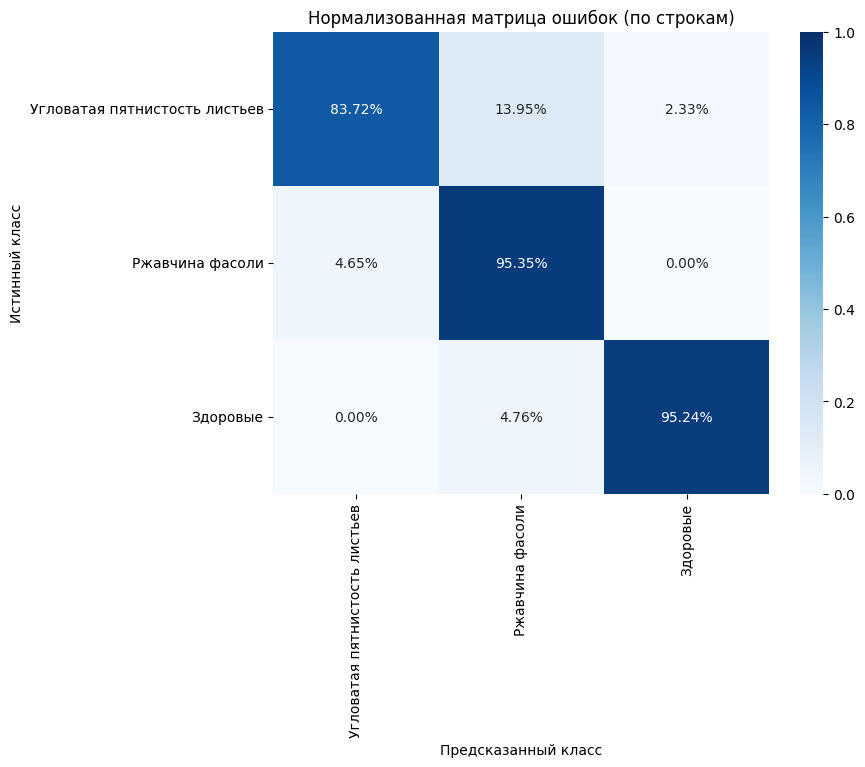

Точность на тестовой выборке: 91.41%


In [ ]:
all_preds = []
all_labels = []
model.eval()
with torch.no_grad():
    for batch in test_loader:
        images = batch["image"].to(device)
        labels = batch["labels"].to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


cm = confusion_matrix(all_labels, all_preds)

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

class_names = train_dataset.features["labels"].names

ru_labels = {
    "angular_leaf_spot": "Угловатая пятнистость листьев",
    "bean_rust": "Ржавчина фасоли",
    "healthy": "Здоровые"
}

class_names_ru = [ru_labels[name] for name in train_dataset.features["labels"].names]


plt.figure(figsize=(8,6))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names_ru, yticklabels=class_names_ru,
            vmin=0, vmax=1)
plt.title("Нормализованная матрица ошибок (по строкам)")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()

# Выводим точность на тесте
test_acc = 100 * np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
print(f"Точность на тестовой выборке: {test_acc:.2f}%")